In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_s_curve, make_swiss_roll
import torch
import torch.nn as nn
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import math


In [2]:
4920/3

1640.0

In [3]:

from google.colab import drive

drive.mount('/content/drive')

%cd /content/drive/MyDrive

Mounted at /content/drive
/content/drive/MyDrive


In [4]:

from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive


### 1.1 IMS dataset
This time we will adopt the real dataset. The experiment will used the IMS dataset and also the phm2012 dataset.
First we will consider the IMS dataset, specifically the No.2 dataset No. 3 bearing (channel).


The test rig can be seen below:


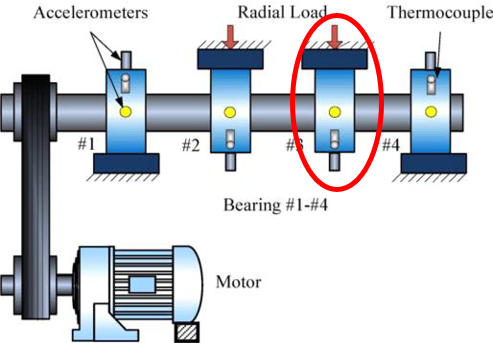



### Training the model using the time-domain data

In [21]:
import scipy.io as scio
from sklearn.model_selection import train_test_split
import pandas as pd
dict_ = scio.loadmat('AE_Diffusion/AE_data_ims/N2_data_C3_.mat')
data_ = dict_['data_c3_']
def normalize(data):
    data_ = (data-np.min(data))/(np.max(data)-np.min(data))
    return data_
#data_h = np.random.randn(1000,4,1024)
data_h = np.random.randn(1000,4,1024)
# data_1 = np.random.randn(4920,4,1024)
data_1 = np.random.randn(4920,4,512)
data_1_ = np.random.randn(4920,4,1024)
ii = 0
for i in range(4920):
  for j in range(4):
    data_1_[i,j,:] = data_[i,1024*j:1024*(j+1)]
    # print(ii)
data_1 = data_1_[:,:,0:512]
data_h = data_1[0:1000,:,:]



In [29]:
# data_b = data_1[4000:4920,:,:]
# data_tv = np.concatenate((data_h, data_b),axis = 0)
data_tv = data_h
# data_test  = data_1[1000:-1,:,:]
yh = np.zeros(1000)
# yu = np.ones(920)
# y_ = np.concatenate((yh,yu))
y_ = yh
data_tr,data_va,y_1,y_v = train_test_split(data_tv, y_, test_size=0.2, random_state=42)

batch_size = 16 #考虑到样本总数仅为1000个,batch_size设定为64个
# dataset放到dataloader中
dataset_tensor = torch.utils.data.TensorDataset(torch.tensor(data_tr,dtype=torch.float32).cuda(),torch.tensor(y_1,dtype = torch.float32).cuda())
#dataloader_1 = torch.utils.data.DataLoader(torch.tensor(data_tr,dtype=torch.float32).cuda(), batch_size=batch_size, shuffle=True)
dataloader_1 = torch.utils.data.DataLoader(dataset_tensor,batch_size=batch_size, shuffle=True)




#### model construction

In [30]:
pip install torch_geometric

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv
from typing import Tuple, Iterator

import torch.nn
from torch.nn import Parameter

In [32]:
class BaseModel(torch.nn.Module):
    def grouped_parameters(self) -> Tuple[Iterator[Parameter], ...]:
        return self.parameters(),


In [33]:
class InputLayer(nn.Module):
    """1-D Convolution layer to extract high-level features of each time-series input
    :param n_features: Number of input features/nodes
    :param window_size: length of the input sequence
    :param kernel_size: size of kernel to use in the convolution operation
    """
    def __init__(self, n_features, kernel_size=7):
        super(InputLayer, self).__init__()
        self.padding = nn.ConstantPad1d((kernel_size - 1) // 2, 0.0)
        self.conv = nn.Conv1d(in_channels=n_features, out_channels=n_features, kernel_size=kernel_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.padding(x)
        x = self.relu(self.conv(x))
        return x.permute(0, 2, 1)  # Permute back


class StgatBlock(nn.Module):
    def __init__(self, n_features, window_size, dropout, alpha, embed_dim=None):
        super(StgatBlock, self).__init__()
        self.n_features = n_features
        self.window_size = window_size
        self.dropout = dropout
        self.alpha = alpha
        self.embed_dim = embed_dim if embed_dim is not None else n_features

        self.embed_dim *= 2

        self.feature_gat_layers = GATConv(window_size, window_size)
        self.temporal_gat_layers = GATConv(n_features, n_features)

        self.temporal_gcn_layers = GCNConv(n_features, n_features)

    def forward(self, data, fc_edge_index, tc_edge_index):
        # x shape (b, n, k): b - batch size, n - window size, k - number of features
        # For feature attention we represent a node as the values of a particular feature across all timestamps
        # ft = data.clone().detach()
        # tp = data.clone().detach()

        # ft = ft.permute(0, 2, 1)
        # batch_num, node_num, all_feature = ft.shape
        # ft = ft.reshape(-1, all_feature).contiguous()
        # f_out = self.feature_gat_layers(ft, fc_edge_index)
        # f_out = F.relu(f_out)
        # f_out = f_out.view(batch_num, node_num, -1)
        # f_out = f_out.permute(0, 2, 1)
        #
        # batch_num, node_num, all_feature = tp.shape
        # tp = tp.reshape(-1, all_feature).contiguous()
        # t_out = self.temporal_gat_layers(tp, tc_edge_index)
        # t_out = F.relu(t_out)
        # t_out = t_out.view(batch_num, node_num, -1)
        #
        # return f_out + t_out   #self.relu(res + h + z)

        x = data.clone().detach()
        x = x.permute(0, 2, 1)
        batch_num, node_num, all_feature = x.shape

        x = x.reshape(-1, all_feature).contiguous()
        # f_out = self.feature_gat_layers(x, fc_edge_index, return_attention_weights = True)
        f_out = self.feature_gat_layers(x, fc_edge_index)
        f_out = F.relu(f_out)
        f_out = f_out.view(batch_num, node_num, -1)
        f_out = f_out.permute(0, 2, 1)
        z = f_out.reshape(-1, node_num).contiguous()

        t_out = self.temporal_gcn_layers(z, tc_edge_index)
        t_out = F.relu(t_out)
        t_out = t_out.view(batch_num, node_num, -1)

        return t_out.permute(0, 2, 1)   #self.relu(res + h + z)


class BiLSTMLayer(nn.Module):
    def __init__(self, in_dim, hid_dim, n_layers, dropout):
        super(BiLSTMLayer, self).__init__()
        self.hid_dim = hid_dim
        self.n_layers = n_layers
        self.dropout = 0.0 if n_layers == 1 else dropout
        self.bilstm = nn.LSTM(in_dim, hid_dim, num_layers=n_layers, batch_first=True, dropout=self.dropout, bidirectional=True)

    def forward(self, x):
        out, h = self.bilstm(x)
        out = out.permute(1,0,2)[-1, :, :] #, h[-1, :, :]  # Extracting from last layer
        return out


class BiLSTMDecoder(nn.Module):
    def __init__(self, in_dim, hid_dim, n_layers, dropout):
        super(BiLSTMDecoder, self).__init__()
        self.in_dim = in_dim
        self.dropout = 0.0 if n_layers == 1 else dropout
        self.bilstm = nn.LSTM(in_dim, hid_dim, num_layers=n_layers, batch_first=True, dropout=self.dropout, bidirectional=True)

    def forward(self, x):
        decoder_out, _ = self.bilstm(x)
        return decoder_out


class ReconstructionModel(nn.Module):
    def __init__(self, window_size, in_dim, hid_dim, out_dim, n_layers, dropout):
        super(ReconstructionModel, self).__init__()
        self.window_size = window_size
        self.decoder = BiLSTMDecoder(in_dim, hid_dim, n_layers, dropout)
        self.fc = nn.Linear(2 * hid_dim, out_dim)

    def forward(self, x):
        # x will be last hidden state of the GRU layer
        h_end = x
        h_end_rep = h_end.repeat_interleave(self.window_size, dim=1).view(x.size(0), self.window_size, -1)
        decoder_out = self.decoder(h_end_rep)
        out = self.fc(decoder_out)
        return out


class Forecasting_Model(nn.Module):
    def __init__(self, in_dim, hid_dim, out_dim, n_layers, dropout):
        super(Forecasting_Model, self).__init__()
        layers = [nn.Linear(in_dim, hid_dim)]
        for _ in range(n_layers - 1):
            layers.append(nn.Linear(hid_dim, hid_dim))

        layers.append(nn.Linear(hid_dim, out_dim))

        self.layers = nn.ModuleList(layers)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        for i in range(len(self.layers) - 1):
            x = self.relu(self.layers[i](x))
            x = self.dropout(x)
        return self.layers[-1](x)


def get_batch_edge_index(org_edge_index, batch_num, node_num):
    # org_edge_index:(2, edge_num)
    edge_index = org_edge_index.clone().detach()
    edge_num = org_edge_index.shape[1]
    batch_edge_index = edge_index.repeat(1,batch_num).contiguous()

    for i in range(batch_num):
        batch_edge_index[:, i*edge_num:(i+1)*edge_num] += i*node_num

    return batch_edge_index.long()


# graph is 'fully-connect'
def get_fc_graph_struc(n_features):
    edge_indices = torch.tensor([[i, j] for j in range(n_features) for i in range(n_features) if i != j])
    return edge_indices.T.contiguous()


def get_tc_graph_struc(temporal_len):
    edge_indices = torch.tensor([[i, j] for j in range(temporal_len) for i in range(j)])
    return edge_indices.T.contiguous()


class STGAT(BaseModel):
    def __init__(self, input_dim: int, window_size: int, embed_dim: int = None, layer_numb: int = 2,
                 lstm_n_layers: int = 1, lstm_hid_dim: int = 150, recon_n_layers: int = 1, recon_hid_dim: int = 150,
                 dropout: float = 0.2, alpha: float = 0.2):
        super(STGAT, self).__init__()

        layers1 = []
        layers2 = []
        layers3 = []

        self.layer_numb = layer_numb
        self.h_temp = []

        self.input_1 = InputLayer(input_dim, 1)
        self.input_2 = InputLayer(input_dim, 5)
        self.input_3 = InputLayer(input_dim, 7)

        for i in range(layer_numb):
            layers1 += [StgatBlock(input_dim, window_size, dropout, alpha, embed_dim)]
        for i in range(layer_numb):
            layers2 += [StgatBlock(input_dim, window_size, dropout, alpha, embed_dim)]
        for i in range(layer_numb):
            layers3 += [StgatBlock(input_dim, window_size, dropout, alpha, embed_dim)]

        self.stgat_1 = nn.Sequential(*layers1)
        self.stgat_2 = nn.Sequential(*layers2)
        self.stgat_3 = nn.Sequential(*layers3)

        self.bilstm = BiLSTMLayer(input_dim * 3, lstm_hid_dim, lstm_n_layers, dropout)
        self.recon_model = ReconstructionModel(window_size, 2 * lstm_hid_dim, recon_hid_dim, input_dim, recon_n_layers,
                                               dropout)

        # Register as buffers so that tensors are moved to the correct device along with the rest of the model
        self.register_buffer('fc_edge_index', get_fc_graph_struc(input_dim), persistent=False)
        self.register_buffer('tc_edge_index', get_tc_graph_struc(window_size), persistent=False)

    def forward(self, inputs):
        # x (B, T, D)
        x, = inputs

        # x shape (b, n, k): b - batch size, n - window size, k - number of features
        fc_edge_index_sets = get_batch_edge_index(self.fc_edge_index, x.shape[0], x.shape[2])
        tc_edge_index_sets = get_batch_edge_index(self.tc_edge_index, x.shape[0], x.shape[1])

        h_cat_1 = x
        h_cat_2 = self.input_2(x)
        h_cat_3 = self.input_3(x)

        for layer in range(self.layer_numb):
            h_cat_1 = h_cat_1 + self.stgat_1[layer](h_cat_1, fc_edge_index_sets, tc_edge_index_sets)
            h_cat_2 = h_cat_2 + self.stgat_2[layer](h_cat_2, fc_edge_index_sets, tc_edge_index_sets)
            h_cat_3 = h_cat_3 + self.stgat_3[layer](h_cat_3, fc_edge_index_sets, tc_edge_index_sets)

        h_cat = torch.cat([h_cat_1, h_cat_2, h_cat_3], dim=2)

        out_end = self.bilstm(h_cat)
        h_end = out_end.view(x.shape[0], -1)   # Hidden state for last timestamp

        recons = self.recon_model(h_end)

        return recons

(self, input_dim: int, window_size: int, split_folds: int = 5,
                 attention_heads: int = 12, attention_layers: int = 4, dropout: float = 0.0)

#### Trying to train the model

In [34]:
model_T = STGAT(input_dim=512,window_size=4).cuda()
num_epoch = 100

seed = 3407
torch.cuda.manual_seed(seed)
dataloader = dataloader_1
optimizer_ = torch.optim.Adam(model_T.parameters(),lr = 1e-4)
# loss_ = OmniAnomalyLoss()
loss_ = nn.MSELoss()

num_epoch = 1000

# epoch遍历
for t in range(num_epoch):
    # dataloader遍历
    model_T.train()
    for idx, (batch_x, batch_y) in enumerate(dataloader):
      # batch_x = batch_x.permute(2,0,1)
      predictions= model_T((batch_x,))
      targets = batch_x
      optimizer_.zero_grad()
      loss = loss_(predictions,targets)
      loss.backward()
      optimizer_.step()
    print(
            "[Epoch %d/%d]   [loss_ %f] "
                % (t,num_epoch, loss.item())
        )

[Epoch 0/1000]   [loss_ 0.010825] 
[Epoch 1/1000]   [loss_ 0.010793] 
[Epoch 2/1000]   [loss_ 0.010556] 
[Epoch 3/1000]   [loss_ 0.010462] 
[Epoch 4/1000]   [loss_ 0.009968] 
[Epoch 5/1000]   [loss_ 0.009308] 
[Epoch 6/1000]   [loss_ 0.009179] 
[Epoch 7/1000]   [loss_ 0.009109] 
[Epoch 8/1000]   [loss_ 0.008917] 
[Epoch 9/1000]   [loss_ 0.008567] 
[Epoch 10/1000]   [loss_ 0.008509] 
[Epoch 11/1000]   [loss_ 0.008058] 
[Epoch 12/1000]   [loss_ 0.008210] 
[Epoch 13/1000]   [loss_ 0.007828] 
[Epoch 14/1000]   [loss_ 0.007536] 
[Epoch 15/1000]   [loss_ 0.007643] 
[Epoch 16/1000]   [loss_ 0.007447] 
[Epoch 17/1000]   [loss_ 0.007424] 
[Epoch 18/1000]   [loss_ 0.007194] 
[Epoch 19/1000]   [loss_ 0.007022] 
[Epoch 20/1000]   [loss_ 0.006941] 
[Epoch 21/1000]   [loss_ 0.006882] 
[Epoch 22/1000]   [loss_ 0.006928] 
[Epoch 23/1000]   [loss_ 0.006690] 
[Epoch 24/1000]   [loss_ 0.006774] 
[Epoch 25/1000]   [loss_ 0.006770] 
[Epoch 26/1000]   [loss_ 0.006648] 
[Epoch 27/1000]   [loss_ 0.006587] 
[E

KeyboardInterrupt: 

In [ ]:
# # o1,o2,o3,o4,o5,o6 = model_T((data_tv,))
# data_tv_ = data_tv.reshape(1024,-1,4)
# o3 = o3.reshape(1024,-1,4)
# o4 =o4.reshape(1024,-1,4)
# aa = F.gaussian_nll_loss(o3[-1], data_tv_[-1], o4[-1]**2, reduction='none')

In [ ]:
4920/2


2460.0

In [35]:
anomaly_scores = torch.ones(984).cuda()
with torch.no_grad():
  data_tv_ = torch.tensor(data_1,dtype = torch.float32).cuda()
  # data_tv = data_tv.permute(2,0,1)
  model_T.eval()
  for i in range(984):
    print(i)
    temp = data_tv_[5*i:5*i+1,:,:]
    rec_ = model_T((temp,))
    anomaly_scores[i] = loss_(temp,rec_)
  # ano_detetcor = OmniAnomalyDetector(model_T)
  # for i in range(2000):
  #   print(i)
  #   anomaly_scores[i] = ano_detetcor.compute_online_anomaly_score((data_tv[:,i:(i+1),:],))
  # # anomaly_scores = ano_detetcor.compute_online_anomaly_score((data_tv,))


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

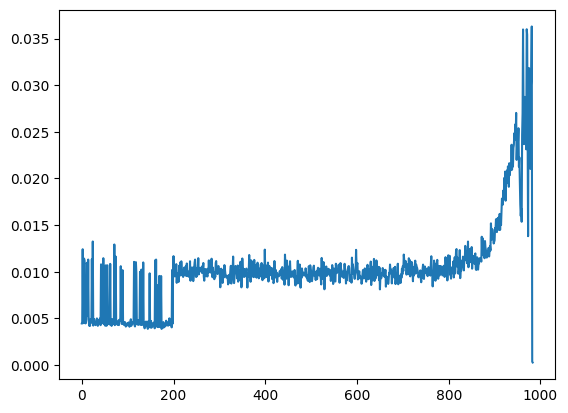

In [36]:
plt.plot(anomaly_scores.cpu().numpy())

In [ ]:
# torch.save('AE_Diffusion/AE_data_ims/anomaly_score_1000_IMS_SIS_VAE.mat',{'anomaly_scores',anomaly_scores.detach().cpu().numpy()})

In [ ]:
HI_m_ = anomaly_scores.detach().cpu().numpy()
HI_m = np.ones(5)
for i in range(5):
  HI_m[i] = np.mean(HI_m_[100*i:100*(i+1)])


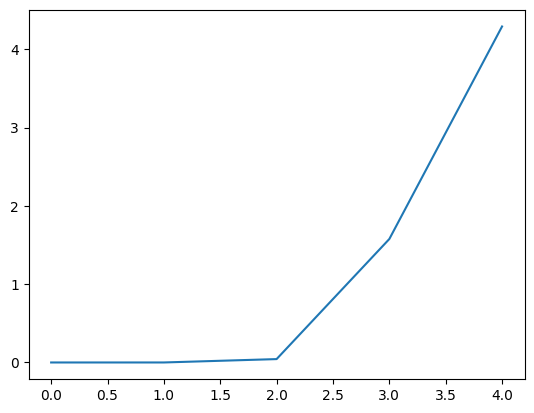

In [ ]:
plt.plot(HI_m)

In [ ]:
import scipy.io as scio
HI_t = HI_m
HI_t_ = HI_m_
scio.savemat('AE_Diffusion/AE_data_ims/result_1000_IMS_stgat.mat',{'HI_t':HI_t,'HI_t_':HI_t_})

#### Case I